In [47]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import glob
import os

In [48]:
# Load privately owned public spaces and format the data
spaces = pd.read_csv("Privately_Owned_Public_Spaces__POPS__20250310.csv")
spaces = spaces.dropna(subset=["Latitude", "Longitude", "Year_Completed"])
# remove 0 values
spaces = spaces[spaces["Year_Completed"] != 0]

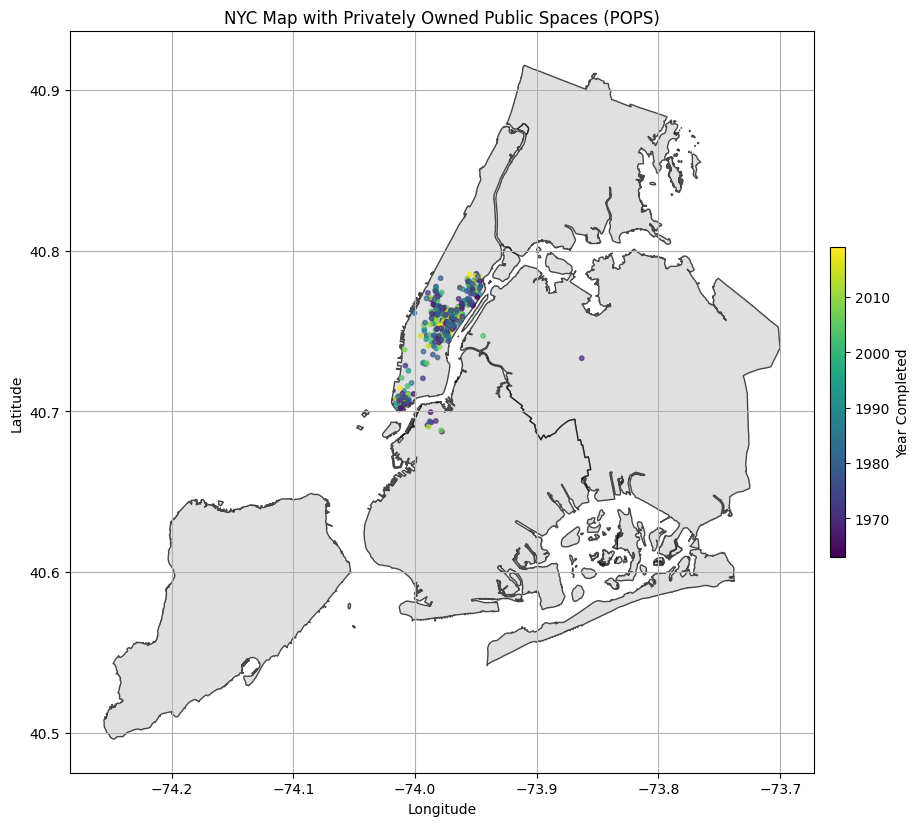

In [49]:
# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(spaces["Longitude"], spaces["Latitude"]), 
    crs="EPSG:4326"
)

# Read NYC map
nyc_map = gpd.read_file(get_path("nybb")).to_crs(epsg=4326)

# Define colormap and normalization
cmap = plt.cm.viridis  # Use the viridis colormap
norm = mcolors.Normalize(vmin=spaces["Year_Completed"].min(), vmax=spaces["Year_Completed"].max())

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
nyc_map.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)

# Plot points with assigned colors
gdf_points.plot(ax=ax, cmap=cmap, markersize=10, alpha=0.7)

# Create a colorbar (sidebar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Year Completed")

# Titles and labels
plt.title("NYC Map with Privately Owned Public Spaces (POPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

In [50]:
# Load all NYC SAFMR data
input_files_path = os.path.join("safmr_filtered", "*.csv")
input_files = glob.glob(input_files_path)

yearly_zip_code_rents = {}

for file in input_files:
    df = pd.read_csv(file)

    df['ZIP Code'] = df['ZIP Code'].astype(str)
    df['SAFMR 0BR - 90% Payment Standard'] = df['SAFMR 0BR - 90% Payment Standard'].replace({'\$': '', ',': ''}, regex=True).astype(float)
    df_filtered = df[['ZIP Code', 'SAFMR 0BR - 90% Payment Standard']]

    zip_values = dict(zip(df_filtered['ZIP Code'], df_filtered['SAFMR 0BR - 90% Payment Standard']))

    year = os.path.basename(file).split('.')[0][2:]  # Extract year from filename
    yearly_zip_code_rents[year] = zip_values

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_16624\1575835101.py:11: SyntaxWarning: invalid escape sequence '\$'
  df['SAFMR 0BR - 90% Payment Standard'] = df['SAFMR 0BR - 90% Payment Standard'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [51]:
yearly_zip_code_rents.keys()

dict_keys(['2019', '2021', '2022', '2023', '2024', '2025'])

In [52]:
gdf = gpd.read_file('zipcode/geo_export_b459f634-6bcb-46d7-ade3-b0ef95b76ebc.shp')

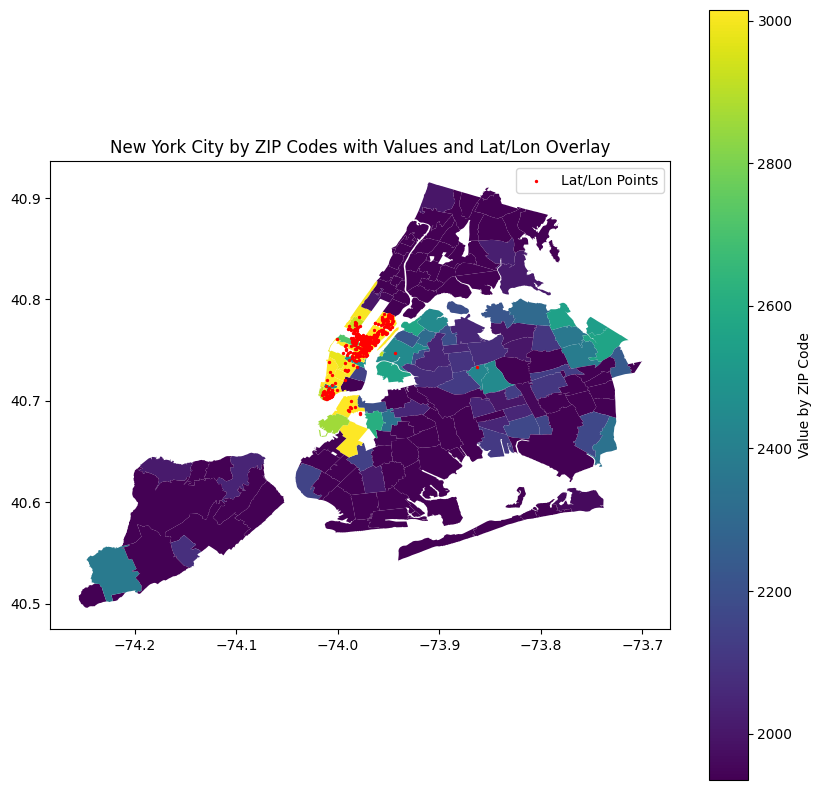

In [53]:
zip_values = yearly_zip_code_rents['2025']
gdf['value'] = gdf['label'].map(zip_values)
gdf = gdf.dropna(subset=['value'])

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf['value'].min(), vmax=gdf['value'].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(ax=ax, column='value', cmap=cmap, legend=True, legend_kwds={'label': "Value by ZIP Code", 'orientation': "vertical"})

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=2, label="Lat/Lon Points")


ax.set_title("New York City by ZIP Codes with Values and Lat/Lon Overlay")
ax.legend()

plt.show()